# 12-bcr-influenza-gene-usage

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import tarfile
import re
import warnings
from data.cell_type import annotate_cells
warnings.filterwarnings('ignore')

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
metadata = pd.read_csv(DATA / "metadata.csv", dtype={"patient": str}).set_index("patient")
metadata

,sex,age,ethnicity,race
patient,,,,
09,female,25,Not Hispanic or Latino,white
94,female,66,Not Hispanic or Latino,white


In [3]:
def extract_tar(tar_path: Path, dest: Path) -> Path:
  if not dest.exists():
    with tarfile.open(tar_path, "r:gz") as tf:
      tf.extractall(dest)
  return dest

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData]:
  cellranger_tar = next(path.glob("*_cellranger.tar.gz"))
  bcrvdj_tar = next(path.glob("*_BCRVDJ.tar.gz"))

  cellranger_dir = extract_tar(cellranger_tar, path / "cellranger")
  bcrvdj_dir = extract_tar(bcrvdj_tar, path / "BCRVDJ")
  contig_csv = next(bcrvdj_dir.glob("**/filtered_contig_annotations.csv"))

  adata_gex = sc.read_10x_mtx(cellranger_dir, var_names="gene_symbols", compressed=False)
  adata_gex.var_names_make_unique()

  adata_tcr = ir.io.read_10x_vdj(contig_csv)
  ir.pp.index_chains(adata_tcr)
  ir.tl.chain_qc(adata_tcr)

  return adata_gex, adata_tcr

def add_metadata(mdata: mu.MuData):
  cell_samples = mdata.obs_names.to_series().str.split("_", expand=True)[1]
  cell_patient = cell_samples.str.split("-", expand=True)[0]

  mdata.obs["sample"] = cell_samples
  mdata.obs["patient"] = cell_patient
  mdata.obs["days_after_vaccination"] = cell_samples.str.split("-", expand=True)[1].astype(int)
  mdata.obs["age"] = cell_patient.map(metadata["age"])
  mdata.obs["sex"] = cell_patient.map(metadata["sex"])
  mdata.obs["young"] = mdata.obs["age"] < 40
  mdata.push_obs()

In [4]:
adatas_gex = {}
adatas_tcr = {}

for sample_dir in sorted(DATA.iterdir()):
  match = re.match(r"(\d+)-(\d+)", sample_dir.name)

  if not sample_dir.is_dir() or not match:
      continue

  sample = sample_dir.name
  gex, tcr = read_sample(sample_dir)

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")

mdata = mu.MuData({"gex": adata_gex, "airr": adata_tcr})
add_metadata(mdata)
mdata

MuData object with n_obs × n_vars = 55114 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	49339 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      layers:	None
    airr:	46331 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [5]:
adata = mdata['gex']
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
mdata

MuData object with n_obs × n_vars = 55114 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	49339 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	None
    airr:	46331 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical


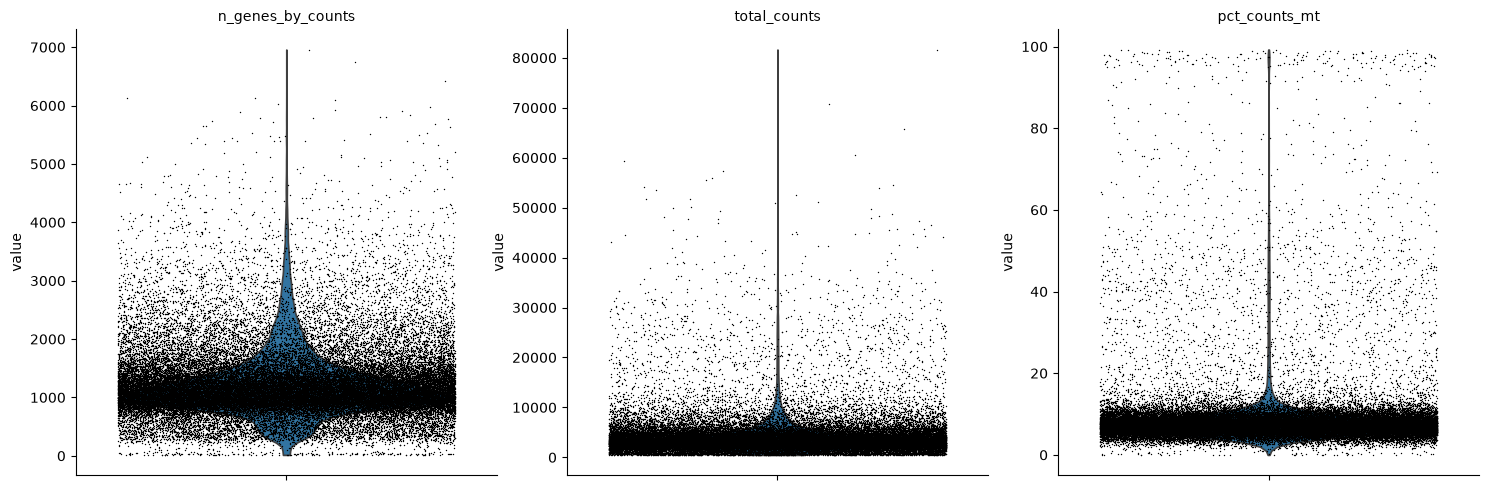

In [6]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)

In [7]:
sc.pp.filter_cells(mdata['gex'], min_genes=200)
sc.pp.filter_genes(mdata['gex'], min_cells=3)
mu.pp.filter_obs(mdata['gex'], 'pct_counts_mt', lambda x: x < 15)
mdata.update()
mu.pp.intersect_obs(mdata)

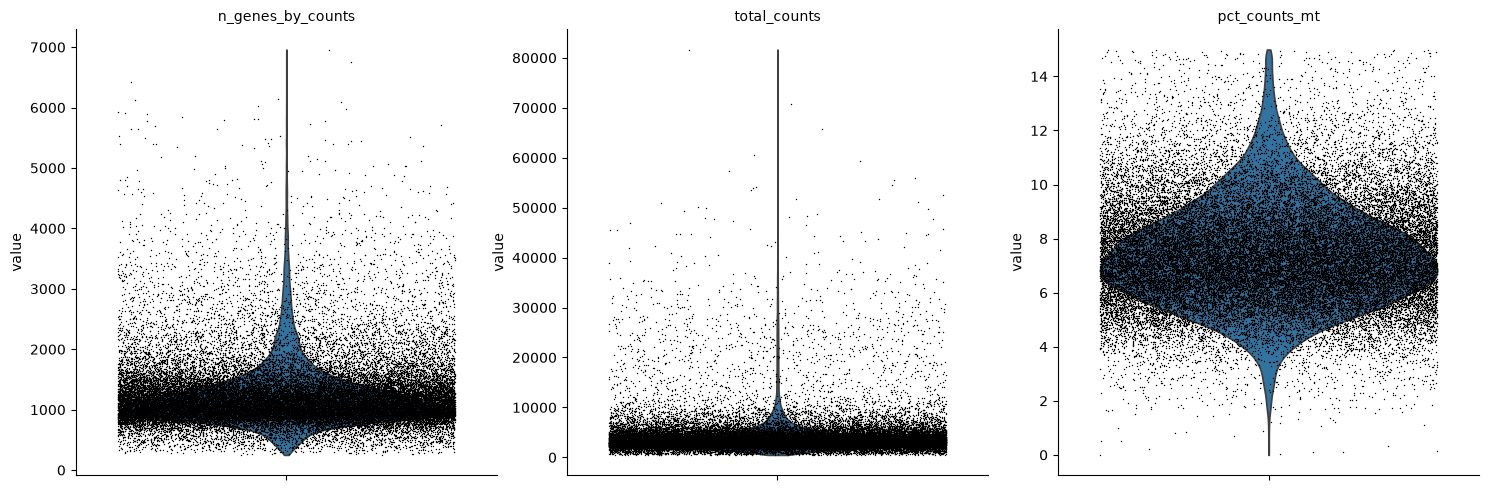

MuData object with n_obs × n_vars = 39922 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	39922 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	39922 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [8]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)
mdata

In [9]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x == "single pair")
mdata.update()
mu.pp.intersect_obs(mdata)
mdata

MuData object with n_obs × n_vars = 29101 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	29101 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	29101 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [10]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])

In [11]:
annotate_cells(mdata)

🔬 Input data has 29101 cells and 20516 genes
🔗 Matching reference genes in the model
🧬 5645 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 29101 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	29101 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p', 'neighbors', 'over_clustering'
      obsm:	'X_pca'
      layers:	None, 'counts'
      obsp:	'connectivities', 'distances'
    airr:	29101 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [12]:
before_vaccination = mdata.copy()
after_vaccination = mdata.copy()

mu.pp.filter_obs(before_vaccination, 'days_after_vaccination', lambda x: x == 0)
mu.pp.filter_obs(after_vaccination, 'days_after_vaccination', lambda x: x == 7)

In [67]:
def define_clonotypes(mdata: mu.MuData) -> mu.MuData:
  ir.pp.ir_dist(mdata)
  ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
  ir.tl.clonotype_network(mdata, min_cells=3)

  ir.pp.ir_dist(mdata, metric="tcrdist", sequence="aa", cutoff=15,)
  ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

  ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")
  ir.tl.clonal_expansion(mdata)
  ir.tl.clonotype_convergence(mdata, key_coarse="cc_aa_tcrdist", key_fine="clone_id")

  return mdata

In [13]:
sc.pp.neighbors(before_vaccination['gex'])
sc.pp.neighbors(after_vaccination['gex'])
sc.tl.umap(before_vaccination['gex'])
sc.tl.umap(after_vaccination['gex'])

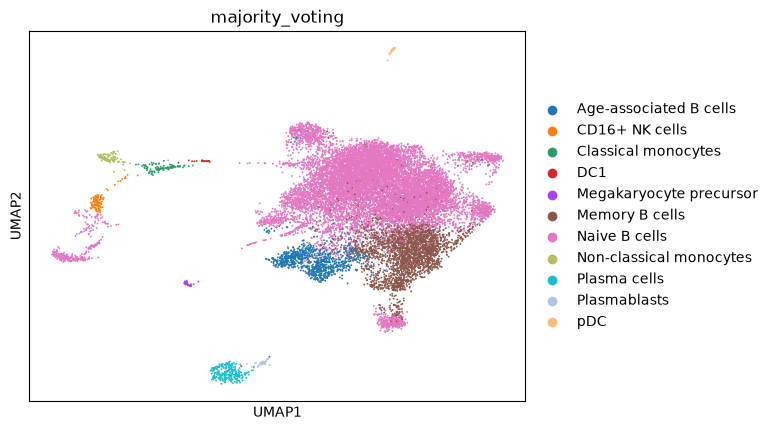

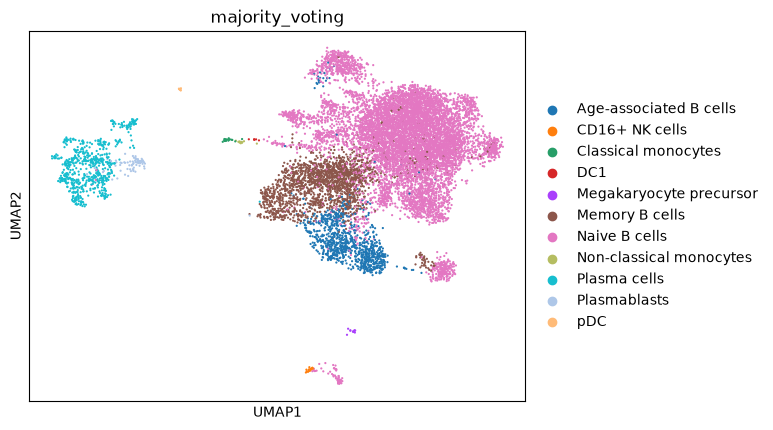

In [14]:
sc.pl.umap(
  before_vaccination['gex'],
  color="majority_voting",
)

sc.pl.umap(
  after_vaccination['gex'],
  color="majority_voting",
)

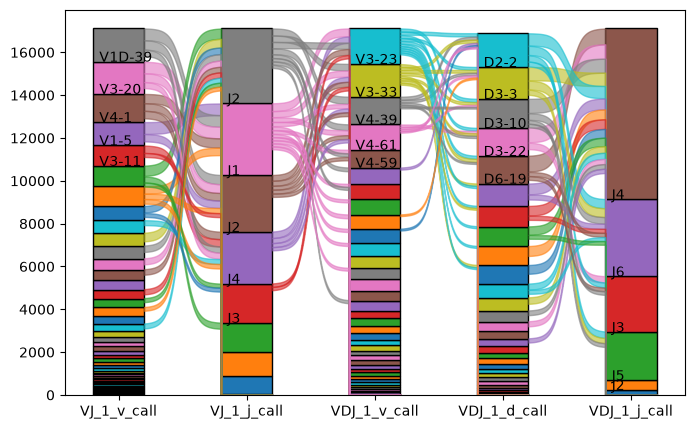

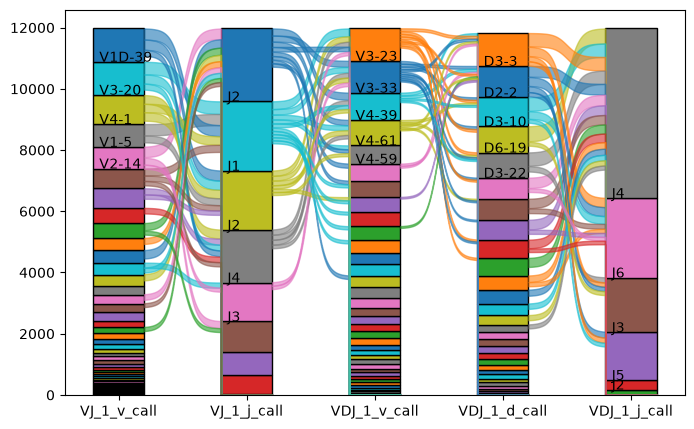

In [15]:
_ = ir.pl.vdj_usage(
  before_vaccination,
  full_combination=False,
  max_segments=None,
  max_ribbons=30,
  fig_kws={"figsize": (8, 5)},
)

_ = ir.pl.vdj_usage(
  after_vaccination,
  full_combination=False,
  max_segments=None,
  max_ribbons=30,
  fig_kws={"figsize": (8, 5)},
)

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:sex' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical
... storing 'VJ_1_v_call' as categorical
... storing 'VDJ_1_v_call' as categorical
... storing 'VJ_2_v_call' as categorical
... storing 'VDJ_2_v_call' as categorical


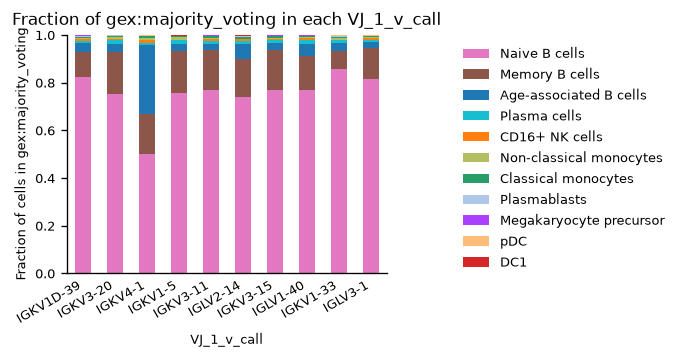

In [22]:
with ir.get.airr_context(before_vaccination, "v_call"):
  ir.pl.group_abundance(
    before_vaccination,
    groupby="VJ_1_v_call",
    target_col="gex:majority_voting",
    normalize=True,
    max_cols=10,
  )

In [23]:
before_vaccination_young = mdata.copy()
before_vaccination_old = mdata.copy()

mu.pp.filter_obs(before_vaccination_young, 'days_after_vaccination', lambda x: x == 0)
mu.pp.filter_obs(before_vaccination_young, 'young', lambda x: x)

mu.pp.filter_obs(before_vaccination_old, 'days_after_vaccination', lambda x: x == 0)
mu.pp.filter_obs(before_vaccination_old, 'young', lambda x: ~x)

... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical
... storing 'VJ_1_v_call' as categorical
... storing 'VDJ_1_v_call' as categorical
... storing 'VJ_2_v_call' as categorical
... storing 'VDJ_2_v_call' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical
... storing 'VJ_1_v_call' as categorical
... storing 'VDJ_1_v_call' as categorical
... storing 'VJ_2_v_call' as categorical
... storing 'VDJ_2_v_call' as categorical


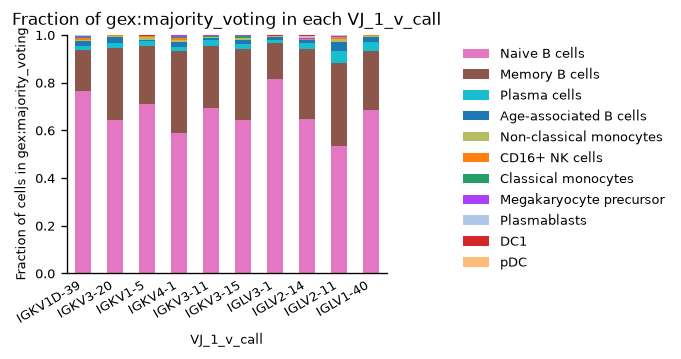

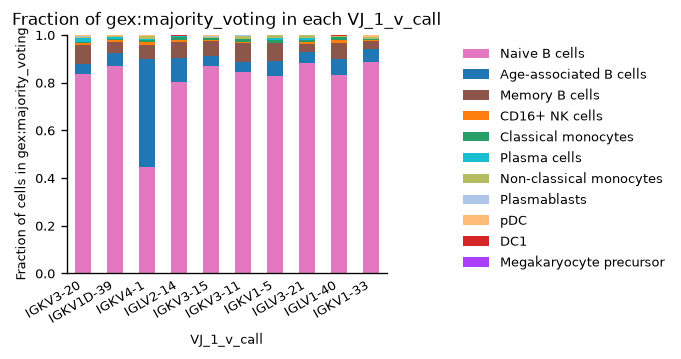

In [24]:
with ir.get.airr_context(before_vaccination_young, "v_call"):
  ir.pl.group_abundance(
    before_vaccination_young,
    groupby="VJ_1_v_call",
    target_col="gex:majority_voting",
    normalize=True,
    max_cols=10,
  )

with ir.get.airr_context(before_vaccination_old, "v_call"):
  ir.pl.group_abundance(
    before_vaccination_old,
    groupby="VJ_1_v_call",
    target_col="gex:majority_voting",
    normalize=True,
    max_cols=10,
  )

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:sex' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical


<Axes: title={'center': 'Spectratype of junction_aa by gex:majority_voting'}, xlabel='junction_aa length', ylabel='Number of cells'>

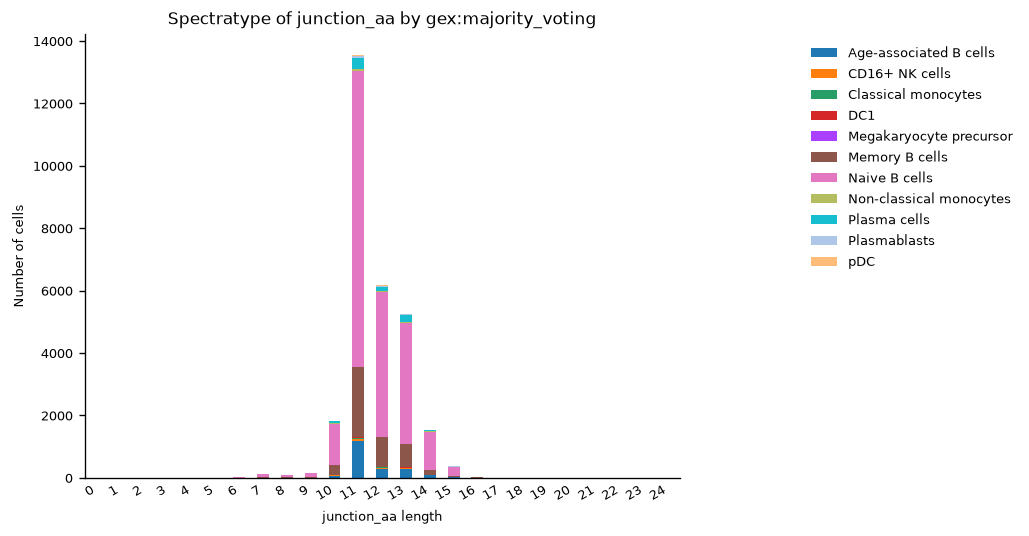

In [33]:
ir.pl.spectratype(mdata, color="gex:majority_voting", viztype="bar", fig_kws={"dpi": 120})

In [60]:
plasmablasts_vdj_junction_length = float(ir.get.airr(
    before_vaccination_young[before_vaccination_young.obs["gex:majority_voting"] == "Plasmablasts"],
    "junction_aa", "VDJ_1"
).str.len().mean())

plasmablasts_vdj_junction_length

17.0

... storing 'VJ_1_j_call' as categorical
... storing 'VDJ_1_j_call' as categorical
... storing 'VJ_2_j_call' as categorical
... storing 'VDJ_2_j_call' as categorical


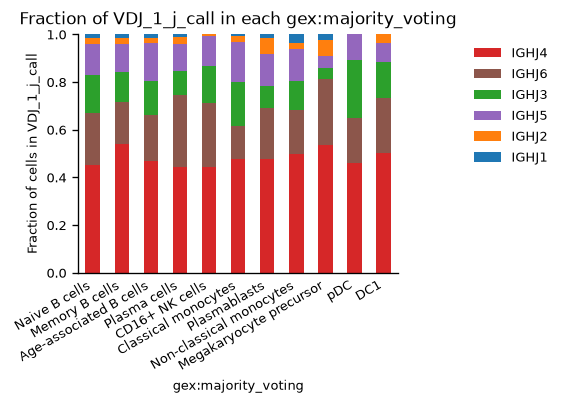

In [68]:
with ir.get.airr_context(mdata, "j_call"):
  ir.pl.group_abundance(
      mdata,
      groupby="gex:majority_voting",
      target_col="VDJ_1_j_call",
      normalize=True,
  )